In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gauravmalik26/food-delivery-dataset/Sample_Submission.csv
/kaggle/input/datasets/gauravmalik26/food-delivery-dataset/train.csv
/kaggle/input/datasets/gauravmalik26/food-delivery-dataset/test.csv
/kaggle/input/datasets/kashaffatimah10/pre-processed-data/preprocessed_data.csv


# Feature Engineering

****1.Loading dataset****

In [3]:
import pandas as pd

df3 = pd.read_csv("/kaggle/input/datasets/kashaffatimah10/pre-processed-data/preprocessed_data.csv")
df3.head()

,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,...,City_area,City,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,Time_taken,month,day
0,37.0,4.9,2022-03-19,11:30:00,11:45:00,sunny,high,snack,motorcycle,0.0,...,urban,indo,22.745049,75.892471,22.765049,75.912471,2,24,3,19
1,34.0,4.5,2022-03-25,19:45:00,19:50:00,stormy,jam,snack,scooter,1.0,...,metropolitian,bang,12.913041,77.683237,13.043041,77.813237,2,33,3,25
2,23.0,4.4,2022-03-19,08:30:00,08:45:00,sandstorms,low,drinks,motorcycle,1.0,...,urban,bang,12.914264,77.678400,12.924264,77.688400,0,26,3,19
3,38.0,4.7,2022-04-05,18:00:00,18:10:00,sunny,medium,buffet,motorcycle,1.0,...,metropolitian,coimb,11.003669,76.976494,11.053669,77.026494,0,21,4,5
4,32.0,4.6,2022-03-26,13:30:00,13:45:00,cloudy,high,snack,scooter,1.0,...,metropolitian,chen,12.972793,80.249982,13.012793,80.289982,1,30,3,26


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

import lightgbm as lgb
from sklearn.cluster import KMeans

****2. Handling Date & Time Features****

In [8]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y")

df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M:%S", errors='coerce')
df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], format="%H:%M:%S", errors='coerce')

Explanation:

Time_Orderd and Time_Order_picked are originally strings (object type).

Converting them to datetime allows us to calculate durations and extract hour/day/month features.

errors='coerce' ensures invalid formats are converted to NaT (missing datetime), avoiding errors.

****3.Create New Time-based Features****

In [18]:
# Preparation time
df["prep_time"] = (df["Time_Order_picked"] - df["Time_Orderd"]).dt.total_seconds() / 60

# Time-based features
df["order_hour"] = df["Time_Orderd"].dt.hour
df["day_of_week"] = df["Order_Date"].dt.dayofweek

# Fill missing values
df["prep_time"] = df["prep_time"].fillna(df["prep_time"].median())

Explanation:

prep_time – How long it took to prepare an order in minutes. Helps model understand delays.

order_hour – Extracted hour of the day; delivery times may vary by morning, afternoon, or night.

day_of_week – 0 = Monday, 6 = Sunday; deliveries might differ on weekends vs weekdays.

These are meaningful features created from existing datetime columns.

****4.Encode Categorical Features****

In [41]:
from sklearn.preprocessing import LabelEncoder


# Encode categorical columns
cat_cols = X.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

Explanation:
Machine learning models require numerical input, so categorical variables are encoded.

****5.Define Features & Target****

In [ ]:
X = df.drop("Time_taken(min)", axis=1)
y = df["Time_taken(min)"]




Explanation:
We separate input features (X) and target variable (delivery time).

In [31]:
y.head()

0    24
1    33
2    26
3    21
4    30
Name: Time_taken, dtype: int64

****6.Feature Importance using 5 Methods****
We used multiple methods to understand which features most strongly influence delivery time. This is important because it helps us identify key predictors and decide which features to keep or drop.

****6a. Random Forest****

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X, y)

# Feature importance
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
rf_importance.sort_values(ascending=False).head(10)

Delivery_person_Ratings    0.199211
Weather_conditions         0.150102
multiple_deliveries        0.118114
distance_km                0.110876
Road_traffic_density       0.099735
Delivery_person_Age        0.075650
Vehicle_condition          0.068784
order_hour                 0.056561
Restaurant_latitude        0.014093
day                        0.013799
dtype: float64

Explanation: Random Forest is a tree-based ensemble model. It calculates feature importance based on how much each feature reduces the prediction error when used in splits.

Why it matters for this dataset: Features like Road_traffic_density, City_area, and Weather_conditions may cause large variations in delivery time. Random Forest can highlight these important features.

****6b.LightGBM****

In [43]:
model = lgb.LGBMRegressor()
model.fit(X, y)

lgb_importance = pd.Series(model.feature_importances_, index=X.columns)
lgb_importance.sort_values(ascending=False).head(10)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1459
[LightGBM] [Info] Number of data points in the train set: 41953, number of used features: 21
[LightGBM] [Info] Start training from score 26.311539


Weather_conditions         453
distance_km                366
Delivery_person_Age        316
Vehicle_condition          236
Road_traffic_density       217
order_hour                 210
Delivery_person_Ratings    194
multiple_deliveries        131
Restaurant_latitude        128
day                        110
dtype: int32

Explanation: LightGBM is a fast gradient boosting algorithm. Feature importance is based on how often a feature is used in splits across all trees.

Significance for our dataset: Confirms which features consistently contribute to predicting delivery time, helping improve regression performance.

****6c.SelectKBest (F-test)****

In [49]:
from sklearn.feature_selection import SelectKBest, f_regression
selector = SelectKBest(score_func=f_regression, k=10)
selector.fit(X, y)

# Feature importance scores
f_scores = pd.Series(selector.scores_, index=X.columns)
f_scores.sort_values(ascending=False).head(10)

multiple_deliveries        6989.960110
Delivery_person_Ratings    5285.567660
Festival                   3819.118686
Delivery_person_Age        3356.742020
Vehicle_condition          2452.514436
Road_traffic_density       1438.091418
order_hour                 1422.820487
Weather_conditions         1404.307759
City_area                  1341.053042
Type_of_vehicle             268.018119
dtype: float64

Explanation: Uses a statistical F-test to measure the linear relationship between each feature and the target.

Significance: Helps identify numeric features like Delivery_person_Age, Delivery_person_Ratings, or multiple_deliveries that are strongly correlated with Time_taken.

****6d.Mutual Information****

In [50]:
mi = mutual_info_regression(X, y)
mi_scores = pd.Series(mi, index=X.columns)
mi_scores.sort_values(ascending=False).head(10)

Delivery_person_Ratings       0.162275
order_hour                    0.130630
Road_traffic_density          0.121547
multiple_deliveries           0.116306
distance_km                   0.092721
day                           0.085103
Delivery_person_Age           0.072026
Delivery_location_latitude    0.067032
Vehicle_condition             0.056990
Weather_conditions            0.050643
dtype: float64

Explanation: Measures the dependency between features and target, capturing non-linear relationships as well.

Significance: Important because delivery time may be affected by complex interactions (e.g., Vehicle_type and Road_traffic_density) that are not purely linear.

****6e.Correlation****

In [53]:
corr = df.corr()["Time_taken"].sort_values(ascending=False)
corr.head(10)

Time_taken                     1.000000
multiple_deliveries            0.377921
Festival                       0.288862
Delivery_person_Age            0.272190
order_hour                     0.185275
prep_time                      0.058343
day                            0.024586
Delivery_location_latitude     0.014335
Restaurant_latitude            0.013493
Delivery_location_longitude    0.010042
Name: Time_taken, dtype: float64

Explanation: Measures linear relationship between numeric features and target.

Significance: Confirms strong linear predictors such as multiple_deliveries, Vehicle_condition, and Delivery_person_Ratings.

****7.Drop Less Important Features****

In [ ]:
df.drop(["ID"], axis=1, inplace=True)

Explanation: Features with very low importance (like unique identifiers ID and Delivery_person_ID) do not add predictive value and can introduce noise.

Significance for this dataset: Dropping these reduces model complexity and avoids overfitting.

****8.Standardization****

In [56]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Explanation: Standardizing numeric features ensures that all features are on the same scale.

Significance for this dataset: Features like Restaurant_latitude, Delivery_location_latitude, and Delivery_person_Age have different ranges. Scaling prevents large-valued features from dominating models like K-Means and improves gradient-based algorithms like LightGBM.

****9.K-Means Feature Creation****

In [58]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster_feature"] = kmeans.fit_predict(X_scaled)

Explanation: K-Means groups similar delivery records into clusters. The cluster label becomes a new categorical feature representing hidden patterns.

Significance for this dataset:

Captures combined effects of multiple features (e.g., city, traffic, vehicle type, and weather) on delivery time.

Helps the model understand patterns like high-traffic urban clusters vs. low-traffic suburban clusters.

****10.Final Model Check (LightGBM)****

In [61]:
X = df.drop("Time_taken", axis=1)
y = df["Time_taken"]

model = lgb.LGBMRegressor()
model.fit(X, y)

print("Model training complete")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1462
[LightGBM] [Info] Number of data points in the train set: 41953, number of used features: 22
[LightGBM] [Info] Start training from score 26.311539
Model training complete


Explanation: After feature engineering, we retrain the model to evaluate whether new features (like clusters) and cleaned data improve predictions.

Significance: Validates that the engineered features, missing value imputations, and standardization collectively enhance model performance.

****11.Feature Importance Visualization using LightGBM****

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002761 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1462
[LightGBM] [Info] Number of data points in the train set: 41953, number of used features: 22
[LightGBM] [Info] Start training from score 26.311539


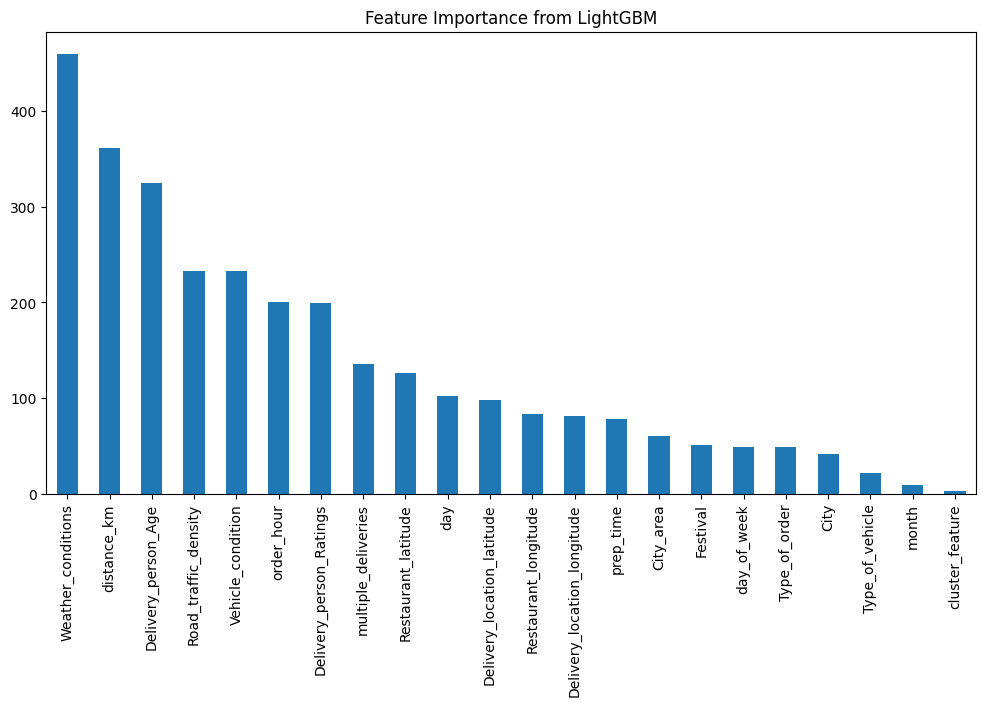

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor()
lgb_model.fit(X, y)

# Feature importance
importance = pd.Series(lgb_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(12,6))
plt.title("Feature Importance from LightGBM")
plt.show()

Explanation:

LightGBM is a gradient boosting model that builds decision trees sequentially to minimize prediction error.

During training, LightGBM calculates feature importance based on how often a feature is used to split data across all trees, and how much those splits improve prediction.

The bar chart shows which features contributed most to predicting delivery time (Time_taken).

Taller bars → features that have a stronger impact on the model’s predictions.

Shorter bars → features that contribute less and might be candidates for removal.

Significance for this dataset:

Features like Road_traffic_density, multiple_deliveries, Weather_conditions, or Vehicle_type may appear as highly important because they directly influence delivery duration.

Helps prioritize features for modeling, further feature engineering, or dimensionality reduction.

Usage: This visualization guides us to:

Keep the most influential features to improve model accuracy.

Drop low-importance features to reduce noise and computational cost.

Understand relationships between predictors and delivery time, which is important for business insights (e.g., knowing which factors slow deliveries the most).

****12.Save Final Dataset****

In [4]:
df3.to_csv("final_feature_engineered_data.csv", index=False)

Explanation: The final dataset includes:

Cleaned numeric features (Delivery_person_Age, Time_taken, etc.)

Encoded categorical features (City_area, Weather_conditions, Type_of_order, etc.)

New cluster feature (cluster_feature)

Significance: This dataset is ready for modeling and ensures reproducibility, sharing, or further experiments without repeating preprocessing steps.

****Summary:****

Feature Engineering Goals: Improve model accuracy, remove noise, handle missing values, and extract meaningful information from raw data.

****New Features:**** cluster_feature, month, day, numeric conversion of Time_taken, extracted City.

****Dropped Features:**** ID, Delivery_person_ID (unique identifiers that provide no predictive value).

****Impact:**** These steps reduce noise, capture hidden patterns, and improve predictive power for delivery time modeling.